In [2]:
from data_extraction import StockTicker
import pandas as pd
import matplotlib.pyplot as plt
import time 

Time Setting


In [3]:
timeframe = '1day'
date_start = '2004-08-19'
date_end = '2013-03-01'

#For the example take:
#timeframe = '1day'
#date_start = '2004-08-19'
#date_end = '2013-03-01'

#### Data Extraction and Cleaning

In [4]:
##RUN ONLY ONCE! Can Block API.
#Companies you want to get data for; Time frame of the data;
tickers1 = ['AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ','GOOG']#, 'AMZN', 'CAT', 'PG', 'NVDA', 'KO']

stocks1 = []
data1 = {}

for j in range(len(tickers1)):
    #Calling the Class StockTicker to get the data for each ticker in the list tickers1.
    stock = StockTicker(symbol=tickers1[j], interval=timeframe, start_date=date_start, end_date=date_end)
    stocks1.append(stock)

    #Taking the data from each each ticker, then formatting it such that the (pandas) index is the time as required by the backtesting library https://kernc.github.io/backtesting.py/doc/examples/Quick%20Start%20User%20Guide.html
    data1[tickers1[j]] = stock.get_data(show=False)
    data1[tickers1[j]].columns = data1[tickers1[j]].columns.str.capitalize()
    data1[tickers1[j]][["Open", "High", "Low", "Close", "Volume"]] = data1[tickers1[j]][["Open", "High", "Low", "Close", "Volume"]].apply(pd.to_numeric)
    data1[tickers1[j]]["Datetime"] = pd.to_datetime(data1[tickers1[j]]["Datetime"])
    data1[tickers1[j]].set_index("Datetime", inplace=True)


In [5]:
#Saves Data as CSV

for j in range(len(tickers1)):
    data1[tickers1[j]].to_csv(f"twelve_data_csv/{tickers1[j]}.csv")

#can then later be read as:
#AAPL = pd.read_csv(f"{twelve_data_csv}/AAPL.csv", index_col="Datetime", parse_dates=True)


### Example: Moving Average Strategy as presented in: https://kernc.github.io/backtesting.py/doc/examples/Quick%20Start%20User%20Guide.html
We code in this strategy to see the workings of the backtesting system, while also using it as a potential metric against other strategies. Note: This code is mostly copy and pasted, except we apply it to our data.
This also guides us to how we should generally formulate/present our strategies with a simple example.

In [6]:
from backtesting import Strategy
from backtesting.lib import crossover
from backtesting import Backtest

#Simple Moving Average (SMA) function
def SMA(values, n):
    """
    Return simple moving average of `values`, at
    each step taking into account `n` previous values.
    """
    return pd.Series(values).rolling(n).mean()

#STRATEGY: SMA Crossover. General idea is to buy when the short-term SMA crosses above the long-term SMA, and sell when the short-term SMA crosses below the long-term SMA.
class SmaCross(Strategy):
    # Define the two MA lags as *class variables*
    # for later optimization
    n1 = 10
    n2 = 20
    
    def init(self):
        # Precompute the two moving averages
        self.sma1 = self.I(SMA, self.data.Close, self.n1)
        self.sma2 = self.I(SMA, self.data.Close, self.n2)
    
    def next(self):
        # If sma1 crosses above sma2, close any existing
        # short trades, and buy the asset
        if crossover(self.sma1, self.sma2):
            self.position.close()
            self.buy()

        # Else, if sma1 crosses below sma2, close any existing
        # long trades, and sell the asset
        elif crossover(self.sma2, self.sma1):
            self.position.close()
            self.sell()
            
bt = Backtest(data1['GOOG'], SmaCross, cash=10_000, commission=.002)
stats = bt.run()
stats

/workspaces/tr_al/.venv/lib/python3.12/site-packages/backtesting/_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

/tmp/ipykernel_20281/2867575635.py:38: UserWarning: Data index is not sorted in ascending order. Sorting.
  bt = Backtest(data1['GOOG'], SmaCross, cash=10_000, commission=.002)
/tmp/ipykernel_20281/2867575635.py:39: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = bt.run()


Start                     2004-08-19 00:00:00
End                       2013-02-28 00:00:00
Duration                   3115 days 00:00:00
Exposure Time [%]                    94.31765
Equity Final [$]                  57425.49393
Equity Peak [$]                   57830.36263
Commissions [$]                   10849.74384
Return [%]                          474.25494
Buy & Hold Return [%]               602.99196
Return (Ann.) [%]                    22.78349
Volatility (Ann.) [%]                37.92475
CAGR [%]                             22.74646
Sharpe Ratio                          0.60076
Sortino Ratio                         1.14918
Calmar Ratio                           0.6672
Alpha [%]                           461.63017
Beta                                  0.02094
Max. Drawdown [%]                     -34.148
Avg. Drawdown [%]                    -6.21777
Max. Drawdown Duration      830 days 00:00:00
Avg. Drawdown Duration       50 days 00:00:00
# Trades                          

In [7]:
bt.plot()

GridPlot(id='p1320', ...)

In [8]:
#Now we do an optimization of our dependnet variables n1 and n2, with the goal of increasing the amount of equity at the end.

stats = bt.optimize(n1=range(5, 30, 5),
                    n2=range(10, 70, 5),
                    maximize='Equity Final [$]',
                    constraint=lambda param: param.n1 < param.n2)

stats

/workspaces/tr_al/.venv/lib/python3.12/site-packages/backtesting/backtesting.py:1652: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
/workspaces/tr_al/.venv/lib/python3.12/site-packages/backtesting/backtesting.py:1652: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)


/workspaces/tr_al/.venv/lib/python3.12/site-packages/backtesting/backtesting.py:1652: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
/workspaces/tr_al/.venv/lib/python3.12/site-packages/backtesting/backtesting.py:1652: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
/workspaces/tr_al/.venv/lib/python3.12/site-packages/backtesting/backtesting.py:1652: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
/workspaces/tr_al/.venv/lib/python3.12/site-packages/backtesting/backtesting.py:1652: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and incl

Start                     2004-08-19 00:00:00
End                       2013-02-28 00:00:00
Duration                   3115 days 00:00:00
Exposure Time [%]                    98.18351
Equity Final [$]                  77992.35218
Equity Peak [$]                    85595.3897
Commissions [$]                   31117.66322
Return [%]                          679.92352
Buy & Hold Return [%]               683.10965
Return (Ann.) [%]                    27.27751
Volatility (Ann.) [%]                43.42233
CAGR [%]                             27.23241
Sharpe Ratio                          0.62819
Sortino Ratio                         1.27609
Calmar Ratio                          0.61148
Alpha [%]                           616.82025
Beta                                  0.09238
Max. Drawdown [%]                   -44.60933
Avg. Drawdown [%]                     -5.8313
Max. Drawdown Duration     1557 days 00:00:00
Avg. Drawdown Duration       50 days 00:00:00
# Trades                          

In [9]:
bt.plot(plot_volume=False, plot_pl=False)

GridPlot(id='p1565', ...)

### Example: Option data extraction

In [10]:
import requests
from decouple import config
import time 
from datetime import datetime, timezone

api_key = config("POLYGON_KEY")

observation_date = "2026-09-11"
next_date = "2026-09-14"

selected_contracts = [7550, 7575, 7600, 7625, 7650, 7675, 7700, 7725, 7750] # Our chosen strikes

timer = 0 #We include a timer to bypass data extraction restrictions, we can only extract 6 tickers' data per minute.

option_prices = []

for strike in selected_contracts:
    timer += 1
    if timer % 6 == 0:
        time.sleep(60)


    ticker = f"O:SPXW260914C{strike * 1000:08d}" # "2026-09-14 expiration date"

    url = (
        f"https://api.massive.com/v2/aggs/ticker/"
        f"{ticker}/range/1/day/{observation_date}/{next_date}"
    )

    params = {
        "adjusted": "true",
        "sort": "asc",
        "limit": 10,
        "apiKey": api_key
    }

    response = requests.get(url, params=params)

    print(strike, response.status_code)

    if response.status_code == 200: #succesfully extracted data

        data = response.json()
        results = data.get("results", [])

        if results:
            bar = results[-1]


            bar_date = datetime.fromtimestamp(
                bar["t"] / 1000,
                tz=timezone.utc
            )


            print(
                "Strike:", strike,
                "Ticker:", ticker,
                "Date:", bar_date,
                "Close:", bar["c"],
                "Volume:", bar["v"]
            )

            option_prices.append(bar["c"])

    else:
        print(f"Error: Potentially No trades for {ticker}, or Request Overflow")

7550 200
Strike: 7550 Ticker: O:SPXW260914C07550000 Date: 2026-09-14 04:00:00+00:00 Close: 70.71 Volume: 941
7575 200
Strike: 7575 Ticker: O:SPXW260914C07575000 Date: 2026-09-14 04:00:00+00:00 Close: 46.45 Volume: 2207
7600 200
Strike: 7600 Ticker: O:SPXW260914C07600000 Date: 2026-09-14 04:00:00+00:00 Close: 21.12 Volume: 47689
7625 200
Strike: 7625 Ticker: O:SPXW260914C07625000 Date: 2026-09-14 04:00:00+00:00 Close: 0.01 Volume: 109255
7650 200
Strike: 7650 Ticker: O:SPXW260914C07650000 Date: 2026-09-14 04:00:00+00:00 Close: 0.03 Volume: 131917
7675 200
Strike: 7675 Ticker: O:SPXW260914C07675000 Date: 2026-09-14 04:00:00+00:00 Close: 0.04 Volume: 21296
7700 200
Strike: 7700 Ticker: O:SPXW260914C07700000 Date: 2026-09-14 04:00:00+00:00 Close: 0.05 Volume: 11122
7725 200
Strike: 7725 Ticker: O:SPXW260914C07725000 Date: 2026-09-14 04:00:00+00:00 Close: 0.03 Volume: 7376
7750 200
Strike: 7750 Ticker: O:SPXW260914C07750000 Date: 2026-09-14 04:00:00+00:00 Close: 0.02 Volume: 2571


[70.71, 46.45, 21.12, 0.01, 0.03, 0.04, 0.05, 0.03, 0.02]


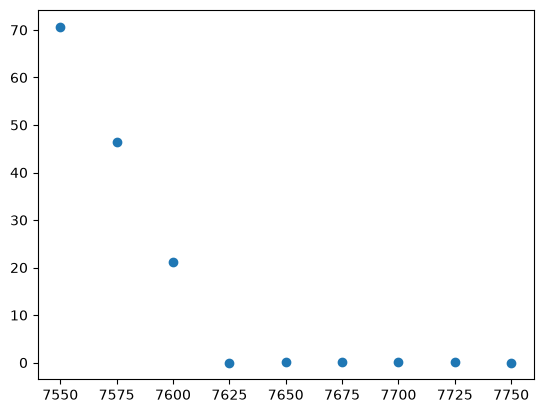

In [ ]:
print(option_prices)

plt.scatter(selected_contracts,option_prices)

### yfinance test

In [50]:
import yfinance as yf
import numpy as np

dat = yf.Ticker("MSFT")
dat.info
dat.calendar
dat.analyst_price_targets
dat.quarterly_income_stmt
dat.history(period='1mo')
dat.option_chain(dat.options[0]).calls


spx = yf.Ticker("^GSPC")
spx.info
df = yf.download("^GSPC", period="5y")




[*********************100%***********************]  1 of 1 completed


[ 1.21347158  0.1461009  -0.27763826 ...  1.49271545 -0.06156417
  0.        ]


(-10.0, 10.0)

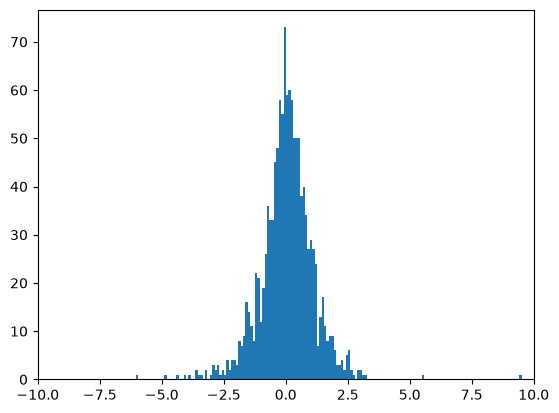

In [57]:
#df.columns

#df['Close']


price = df.to_numpy()[:,0]


def ret(initial,end):
    return 100*(end-initial)/initial
#    return np.log(end/initial)

#print(price)


counts, bin_edges = np.histogram(ret(price[0],price), bins=1000)

ret_invest = np.zeros(len(price-1))
for j in range(len(price)-1):
    ret_invest[j] = ret(price[j],price[j+1])

print(ret_invest)

plt.hist(ret_invest, bins = bin_edges)
plt.xlim(-10,10)

In [ ]:
dat= yf.Ticker("SAP")
dat.option_chain("2026-09-25").calls

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,SAP260925C00165000,2026-08-26 19:59:15+00:00,165.0,47.35,42.40,46.30,0.000000,0.000000,1.0,0,1.074223,True,REGULAR,USD
1,SAP260925C00180000,2026-09-08 18:33:52+00:00,180.0,31.23,28.00,31.40,0.000000,0.000000,3.0,0,0.870607,True,REGULAR,USD
2,SAP260925C00190000,2026-09-11 14:47:16+00:00,190.0,17.89,18.60,21.50,0.000000,0.000000,NaN,1,0.698245,True,REGULAR,USD
3,SAP260925C00195000,2026-09-21 16:09:49+00:00,195.0,15.62,13.60,16.60,-7.269999,-31.760592,1.0,11,0.568364,True,REGULAR,USD
4,SAP260925C00200000,2026-09-21 19:26:18+00:00,200.0,9.40,9.40,12.00,-9.220001,-49.516655,2.0,4,0.510259,True,REGULAR,USD
5,SAP260925C00205000,2026-09-17 15:37:58+00:00,205.0,12.00,5.50,7.80,0.000000,0.000000,1.0,11,0.571293,True,REGULAR,USD
6,SAP260925C00207500,2026-09-18 16:58:42+00:00,207.5,5.40,4.40,4.80,0.000000,0.000000,5.0,5,0.407232,True,REGULAR,USD
7,SAP260925C00210000,2026-09-21 19:32:29+00:00,210.0,3.50,3.10,3.50,-0.700000,-16.666664,11.0,8,0.403082,False,REGULAR,USD
8,SAP260925C00212500,2026-09-21 17:10:24+00:00,212.5,2.40,2.00,2.40,-0.900000,-27.272722,9.0,1,0.393439,False,REGULAR,USD
9,SAP260925C00215000,2026-09-21 18:40:08+00:00,215.0,1.35,1.25,1.60,-0.700000,-34.146340,12.0,26,0.389899,False,REGULAR,USD


In [ ]:
dat.option_chain?

Signature: dat.option_chain(date=None, tz=None)
Docstring: <no docstring>
File:      ~\projects\tr_al\venv\lib\site-packages\yfinance\ticker.py
Type:      method